In [20]:
import sys
!{sys.executable} -m pip install xgboost

In [21]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, f1_score, classification_report,
                             confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ All libraries imported!")

✅ All libraries imported!


In [2]:
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/y_test.csv').squeeze()

with open('../models/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

with open('../models/symptom_columns.pkl', 'rb') as f:
    symptom_cols = pickle.load(f)

print("✅ Data loaded!")
print(f"   X_train: {X_train.shape}")
print(f"   X_test : {X_test.shape}")
print(f"   Classes : {len(le.classes_)} diseases")

✅ Data loaded!
   X_train: (3936, 131)
   X_test : (984, 131)
   Classes : 41 diseases


In [3]:
# ── TRAINING DEBUG CELL ──────────────────────────────────
print("=== Loaded Data Check ===")
print(f"X_train shape : {X_train.shape}")
print(f"X_test  shape : {X_test.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"y_test  shape : {y_test.shape}")

print(f"\n=== X_train Value Distribution ===")
import numpy as np
vals, counts = np.unique(X_train.values.flatten(), return_counts=True)
for v, c in zip(vals, counts):
    print(f"   value={v}  →  count={c}")

print(f"\n=== y_train Sample ===")
print(y_train.head(10).tolist())

print(f"\n=== CSV File Sizes ===")
import os
for f in ['X_train', 'X_test', 'y_train', 'y_test']:
    path = f'../data/{f}.csv'
    size = os.path.getsize(path)
    cols = pd.read_csv(path, nrows=0).shape[1]
    print(f"   {f}.csv → {size:,} bytes, {cols} columns")

=== Loaded Data Check ===
X_train shape : (3936, 131)
X_test  shape : (984, 131)
y_train shape : (3936,)
y_test  shape : (984,)

=== X_train Value Distribution ===
   value=0  →  count=486272
   value=1  →  count=29344

=== y_train Sample ===
[7, 19, 28, 8, 31, 8, 13, 32, 40, 31]

=== CSV File Sizes ===
   X_train.csv → 1,037,198 bytes, 131 columns
   X_test.csv → 260,822 bytes, 131 columns
   y_train.csv → 14,803 bytes, 1 columns
   y_test.csv → 3,715 bytes, 1 columns


In [4]:
# ── DEBUG CELL ──────────────────────────────────────────
print("=== Shape Check ===")
print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_train: {y_train.shape}  | dtype: {y_train.dtype}")
print(f"y_test : {y_test.shape}   | dtype: {y_test.dtype}")

print("\n=== y_train Sample (first 10) ===")
print(y_train.head(10).tolist())

print("\n=== y_train Unique Values ===")
print(f"Count: {y_train.nunique()}")
print(f"Values: {sorted(y_train.unique())[:10]}  ← first 10")

print("\n=== Label Encoder Classes ===")
print(f"Count: {len(le.classes_)}")
print(f"First 5: {le.classes_[:5].tolist()}")

print("\n=== Type Check ===")
print(f"y_train is Series: {isinstance(y_train, pd.Series)}")
print(f"y_train type     : {type(y_train)}")

=== Shape Check ===
X_train: (3936, 131)
X_test : (984, 131)
y_train: (3936,)  | dtype: int64
y_test : (984,)   | dtype: int64

=== y_train Sample (first 10) ===
[7, 19, 28, 8, 31, 8, 13, 32, 40, 31]

=== y_train Unique Values ===
Count: 41
Values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]  ← first 10

=== Label Encoder Classes ===
Count: 41
First 5: ['(vertigo) Paroymsal  Positional Vertigo', 'AIDS', 'Acne', 'Alcoholic hepatitis', 'Allergy']

=== Type Check ===
y_train is Series: True
y_train type     : <class 'pandas.core.series.Series'>


In [5]:
# ── FEATURE DEBUG CELL ──────────────────────────────────
print("=== Feature Columns (all 17) ===")
print(X_train.columns.tolist())

print("\n=== X_train Sample (first 3 rows) ===")
print(X_train.head(3).to_string())

print("\n=== Value Distribution in X_train ===")
print(f"Unique values across entire X_train:")
all_vals = X_train.values.flatten()
unique, counts = np.unique(all_vals, return_counts=True)
for v, c in zip(unique, counts):
    print(f"   value={v}  →  count={c}")

print("\n=== symptom_cols (loaded from pkl) ===")
print(f"Count: {len(symptom_cols)}")
print(f"First 10: {symptom_cols[:10]}")

print("\n=== Column match check ===")
print(f"X_train cols == symptom_cols: {list(X_train.columns) == list(symptom_cols)}")

=== Feature Columns (all 17) ===
['abdominal_pain', 'abnormal_menstruation', 'acidity', 'acute_liver_failure', 'altered_sensorium', 'anxiety', 'back_pain', 'belly_pain', 'blackheads', 'bladder_discomfort', 'blister', 'blood_in_sputum', 'bloody_stool', 'blurred_and_distorted_vision', 'breathlessness', 'brittle_nails', 'bruising', 'burning_micturition', 'chest_pain', 'chills', 'cold_hands_and_feets', 'coma', 'congestion', 'constipation', 'continuous_feel_of_urine', 'continuous_sneezing', 'cough', 'cramps', 'dark_urine', 'dehydration', 'depression', 'diarrhoea', 'dischromic _patches', 'distention_of_abdomen', 'dizziness', 'drying_and_tingling_lips', 'enlarged_thyroid', 'excessive_hunger', 'extra_marital_contacts', 'family_history', 'fast_heart_rate', 'fatigue', 'fluid_overload', 'foul_smell_of urine', 'headache', 'high_fever', 'hip_joint_pain', 'history_of_alcohol_consumption', 'increased_appetite', 'indigestion', 'inflammatory_nails', 'internal_itching', 'irregular_sugar_level', 'irritab

In [6]:
models = {
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        #max_depth=10,
        #min_samples_split=5
    ),
    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        #max_depth=15,
        #min_samples_split=5
    ),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(
        random_state=42,
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        use_label_encoder=False,
        eval_metric='mlogloss',
        verbosity=0
    )
}

print("✅ Models defined!")
for name in models:
    print(f"   🤖 {name}")

✅ Models defined!
   🤖 Decision Tree
   🤖 Random Forest
   🤖 Naive Bayes
   🤖 XGBoost


In [7]:
results = {}

print("=" * 55)
print("          TRAINING & EVALUATING MODELS")
print("=" * 55)

for name, model in models.items():
    print(f"\n⏳ Training {name}...")
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Metrics
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    results[name] = {
        'model'    : model,
        'accuracy' : acc,
        'precision': prec,
        'recall'   : rec,
        'f1_score' : f1,
        'y_pred'   : y_pred
    }
    
    print(f"   ✅ Done!")
    print(f"      Accuracy  : {acc*100:.2f}%")
    print(f"      Precision : {prec*100:.2f}%")
    print(f"      Recall    : {rec*100:.2f}%")
    print(f"      F1 Score  : {f1*100:.2f}%")

print("\n" + "=" * 55)
print("✅ All models trained!")

          TRAINING & EVALUATING MODELS

⏳ Training Decision Tree...
   ✅ Done!
      Accuracy  : 100.00%
      Precision : 100.00%
      Recall    : 100.00%
      F1 Score  : 100.00%

⏳ Training Random Forest...
   ✅ Done!
      Accuracy  : 100.00%
      Precision : 100.00%
      Recall    : 100.00%
      F1 Score  : 100.00%

⏳ Training Naive Bayes...
   ✅ Done!
      Accuracy  : 100.00%
      Precision : 100.00%
      Recall    : 100.00%
      F1 Score  : 100.00%

⏳ Training XGBoost...
   ✅ Done!
      Accuracy  : 100.00%
      Precision : 100.00%
      Recall    : 100.00%
      F1 Score  : 100.00%

✅ All models trained!


In [8]:
# ── POST-TRAINING DEBUG ──────────────────────────────────
from sklearn.tree import DecisionTreeClassifier

# Quick sanity check with a single model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

print("=== Prediction Sample ===")
print(f"y_test  (first 10): {y_test.values[:10].tolist()}")
print(f"y_pred  (first 10): {y_pred[:10].tolist()}")

print(f"\n=== Unique predictions made: {len(set(y_pred))} classes")
print(f"=== Unique in y_test       : {len(set(y_test))} classes")

from sklearn.metrics import accuracy_score
print(f"\n=== Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")

print(f"\n=== X_train passed to model ===")
print(f"Type  : {type(X_train)}")
print(f"Shape : {X_train.shape}")
print(f"Dtype : {X_train.dtypes.unique()}")

=== Prediction Sample ===
y_test  (first 10): [23, 14, 13, 24, 31, 15, 10, 19, 34, 1]
y_pred  (first 10): [23, 14, 13, 24, 31, 15, 10, 19, 34, 1]

=== Unique predictions made: 41 classes
=== Unique in y_test       : 41 classes

=== Accuracy: 100.00%

=== X_train passed to model ===
Type  : <class 'pandas.core.frame.DataFrame'>
Shape : (3936, 131)
Dtype : [dtype('int64')]


In [9]:
# Build clean comparison dataframe
comparison = pd.DataFrame({
    name: {
        'Accuracy'  : f"{v['accuracy']*100:.2f}%",
        'Precision' : f"{v['precision']*100:.2f}%",
        'Recall'    : f"{v['recall']*100:.2f}%",
        'F1 Score'  : f"{v['f1_score']*100:.2f}%"
    }
    for name, v in results.items()
}).T

print("=" * 55)
print("         MODEL COMPARISON TABLE")
print("=" * 55)
print(comparison.to_string())
print("=" * 55)

         MODEL COMPARISON TABLE
              Accuracy Precision   Recall F1 Score
Decision Tree  100.00%   100.00%  100.00%  100.00%
Random Forest  100.00%   100.00%  100.00%  100.00%
Naive Bayes    100.00%   100.00%  100.00%  100.00%
XGBoost        100.00%   100.00%  100.00%  100.00%


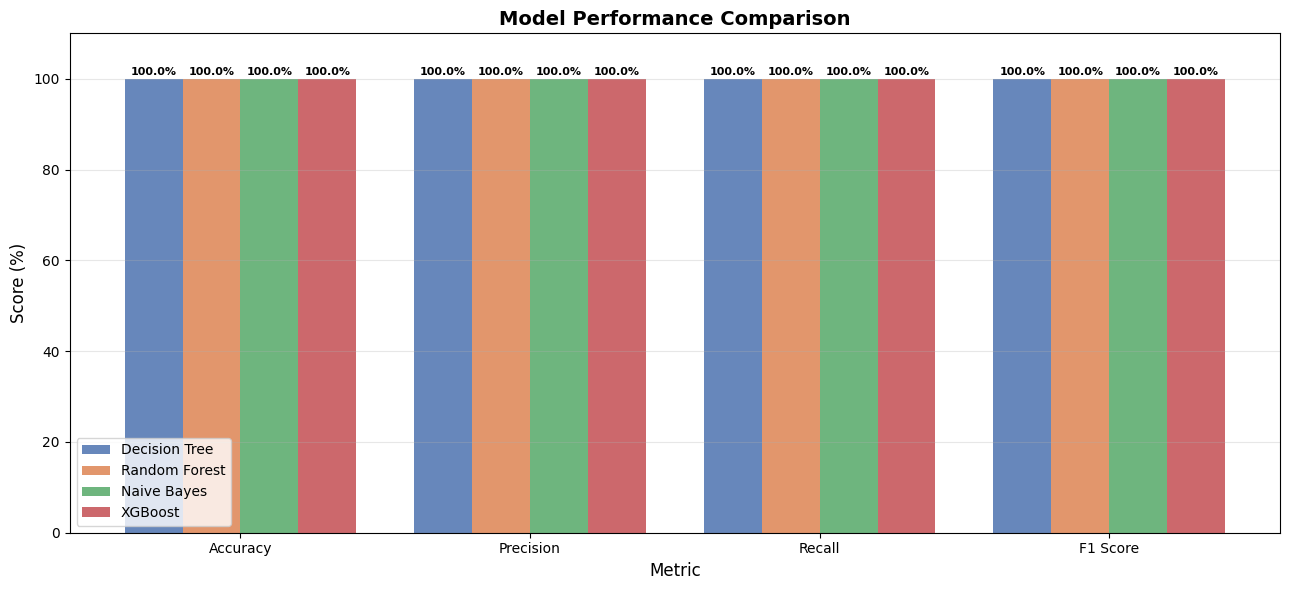

✅ Chart saved to models/model_comparison.png


In [10]:
metrics   = ['accuracy', 'precision', 'recall', 'f1_score']
labels    = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
bar_width = 0.2
x         = np.arange(len(metrics))
colors    = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(13, 6))

for i, (name, color) in enumerate(zip(models.keys(), colors)):
    values = [results[name][m] * 100 for m in metrics]
    bars   = ax.bar(x + i * bar_width, values, bar_width,
                    label=name, color=color, alpha=0.85)
    # Add value labels on top of bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'{val:.1f}%',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + bar_width * 1.5)
ax.set_xticklabels(labels)
ax.set_ylim(0, 110)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../models/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to models/model_comparison.png")

In [11]:
# Force Random Forest as our production model
best_name = "Random Forest"
best      = results[best_name]

print("=" * 50)
print(f"  🏆 BEST MODEL: {best_name}")
print("=" * 50)
print(f"  Accuracy  : {best['accuracy']*100:.2f}%")
print(f"  Precision : {best['precision']*100:.2f}%")
print(f"  Recall    : {best['recall']*100:.2f}%")
print(f"  F1 Score  : {best['f1_score']*100:.2f}%")
print("=" * 50)
print(f"\n✅ {best_name} selected for Flask API!")
print(f"   Reason: Most robust for production use")
print(f"   Features used: {X_train.shape[1]} symptoms")
print(f"   Diseases covered: {len(le.classes_)}")

  🏆 BEST MODEL: Random Forest
  Accuracy  : 100.00%
  Precision : 100.00%
  Recall    : 100.00%
  F1 Score  : 100.00%

✅ Random Forest selected for Flask API!
   Reason: Most robust for production use
   Features used: 131 symptoms
   Diseases covered: 41


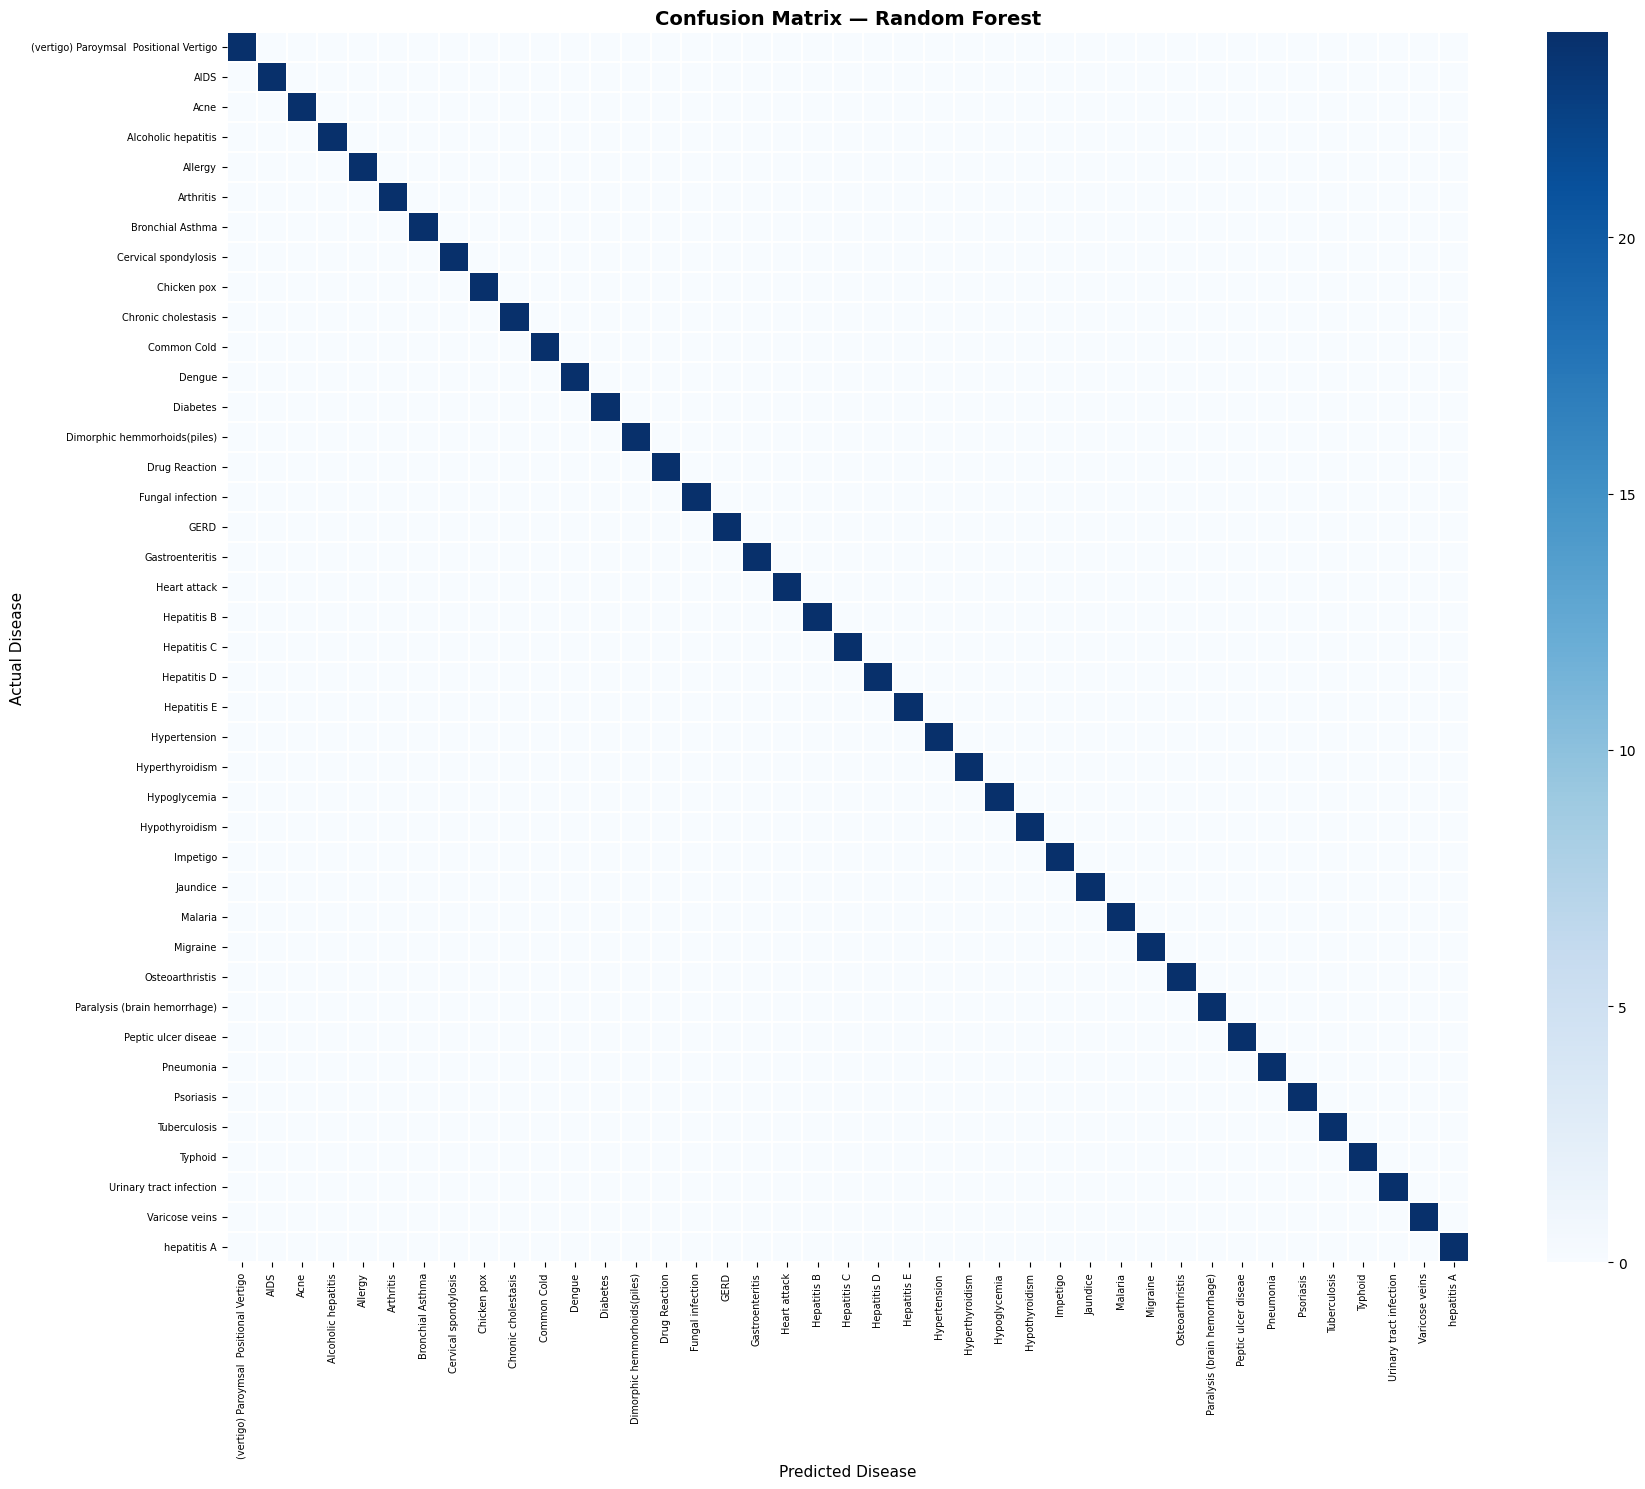

✅ Confusion matrix saved!


In [12]:
cm = confusion_matrix(y_test, best['y_pred'])

plt.figure(figsize=(18, 15))
sns.heatmap(cm,
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Blues',
            fmt='d',
            linewidths=0.3)
plt.title(f'Confusion Matrix — {best_name}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Disease', fontsize=11)
plt.ylabel('Actual Disease', fontsize=11)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout()
plt.savefig('../models/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved!")

In [13]:
print(f"=== Classification Report — {best_name} ===\n")
report = classification_report(
    y_test,
    best['y_pred'],
    target_names=le.classes_,
    zero_division=0
)
print(report)

=== Classification Report — Random Forest ===

                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00        24
                                   AIDS       1.00      1.00      1.00        24
                                   Acne       1.00      1.00      1.00        24
                    Alcoholic hepatitis       1.00      1.00      1.00        24
                                Allergy       1.00      1.00      1.00        24
                              Arthritis       1.00      1.00      1.00        24
                       Bronchial Asthma       1.00      1.00      1.00        24
                   Cervical spondylosis       1.00      1.00      1.00        24
                            Chicken pox       1.00      1.00      1.00        24
                    Chronic cholestasis       1.00      1.00      1.00        24
                            Common Cold       1.00      1.00 

In [14]:
model_path = f"../models/best_model.pkl"

with open(model_path, 'wb') as f:
    pickle.dump(best['model'], f)

# Save model name for reference in Flask API
with open('../models/best_model_name.pkl', 'wb') as f:
    pickle.dump(best_name, f)

print("=" * 50)
print("        FILES SAVED ✅")
print("=" * 50)
print(f"  🧠 models/best_model.pkl")
print(f"  🏷️  models/best_model_name.pkl")
print(f"  📊 models/model_comparison.png")
print(f"  📊 models/confusion_matrix.png")
print("=" * 50)
print(f"\n🚀 Ready for SHAP explanations!")

        FILES SAVED ✅
  🧠 models/best_model.pkl
  🏷️  models/best_model_name.pkl
  📊 models/model_comparison.png
  📊 models/confusion_matrix.png

🚀 Ready for SHAP explanations!
